# 05 — Clustering Analysis

Exploratory unsupervised analysis of the segment-level rhythm feature
dataframe produced in `02_Rhythm_Feature_Extraction.ipynb`. This notebook
does **not** train a classifier and does **not** claim that any cluster
structure proves genre identity. All findings below are exploratory and
descriptive of the numerical feature space only.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sys.path.append("..")
from utils.similarity import get_feature_columns, compute_group_centroids

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
DATA_PATH = Path("../data/extracted/rhythm_features.parquet")
TABLES_DIR = Path("../tables")
FIGURES_DIR = Path("../figures")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load existing rhythm feature dataframe

In [3]:
rhythm_df = pd.read_parquet(DATA_PATH)
rhythm_df.shape


(109089, 41)

## 2. Separate metadata columns and numerical rhythm feature columns

In [4]:
METADATA_COLS = ["genre", "state", "artist", "gender", "song", "source", "source_file"]
metadata_cols = [c for c in METADATA_COLS if c in rhythm_df.columns]

feature_cols = get_feature_columns(rhythm_df, exclude=metadata_cols)
len(metadata_cols), len(feature_cols)


(7, 34)

In [5]:
feature_df = rhythm_df[feature_cols].copy()
meta_df = rhythm_df[metadata_cols].copy()
feature_df.shape, meta_df.shape


((109089, 34), (109089, 7))

## 3. Data quality checks

In [6]:
missing_counts = feature_df.isna().sum()
missing_report = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_report


Series([], dtype: int64)

In [7]:
inf_mask = ~np.isfinite(feature_df.to_numpy())
inf_counts_per_col = pd.Series(inf_mask.sum(axis=0), index=feature_df.columns)
inf_report = inf_counts_per_col[inf_counts_per_col > 0].sort_values(ascending=False)
inf_report


Series([], dtype: int64)

In [8]:
variances = feature_df.var(axis=0)
zero_variance_cols = variances[variances == 0].index.tolist()
zero_variance_cols


['tempogram_stability']

In [9]:
quality_report = pd.DataFrame({
    "missing_values": missing_counts,
    "infinite_values": inf_counts_per_col,
    "variance": variances,
})
quality_report["zero_variance"] = quality_report["variance"] == 0
quality_report.to_csv(TABLES_DIR / "feature_quality_report.csv")
quality_report.head()


,missing_values,infinite_values,variance,zero_variance
energy_mean,0,0,589779.402592,False
energy_std,0,0,44011.535772,False
energy_max,0,0,443707.388555,False
energy_min,0,0,866587.175398,False
energy_range,0,0,532185.175291,False


In [10]:
valid_feature_cols = [c for c in feature_cols if c not in zero_variance_cols]

feature_df_clean = feature_df[valid_feature_cols].copy()
feature_df_clean = feature_df_clean.replace([np.inf, -np.inf], np.nan)
rows_before = len(feature_df_clean)
valid_row_mask = feature_df_clean.notna().all(axis=1)
feature_df_clean = feature_df_clean[valid_row_mask]
meta_df_clean = meta_df[valid_row_mask].reset_index(drop=True)
feature_df_clean = feature_df_clean.reset_index(drop=True)

rows_before, len(feature_df_clean), len(valid_feature_cols)


(109089, 109089, 33)

Rows with non-finite values in any retained feature are excluded only from this clustering analysis (in-memory), consistent with standard unsupervised-analysis practice. The original dataset on disk is not modified.

## 4. Standardize rhythm features

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df_clean.to_numpy())
X_scaled.shape


(109089, 33)

## 5. PCA

In [12]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained_variance_df = pd.DataFrame({
    "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_full.explained_variance_ratio_),
})
explained_variance_df.to_csv(TABLES_DIR / "pca_explained_variance.csv", index=False)
explained_variance_df.head(10)


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.279262,0.279262
1,2,0.216873,0.496134
2,3,0.088517,0.584651
3,4,0.071154,0.655805
4,5,0.051314,0.707119
5,6,0.047483,0.754602
6,7,0.034631,0.789234
7,8,0.029763,0.818997
8,9,0.026612,0.845609
9,10,0.024975,0.870584


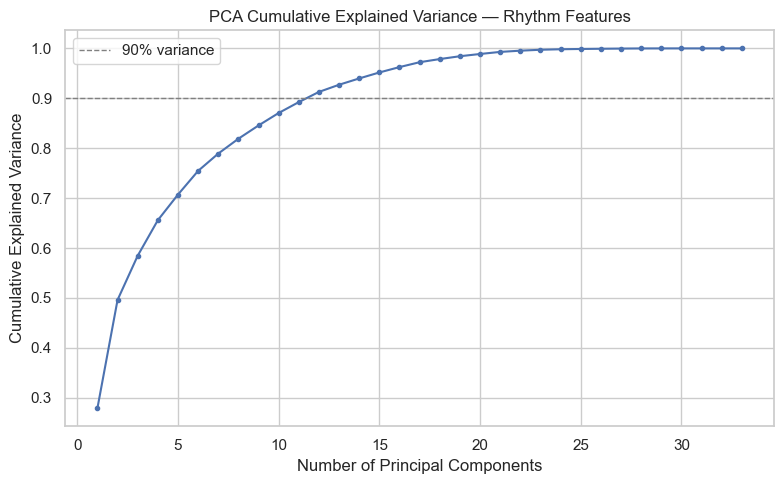

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    explained_variance_df["component"],
    explained_variance_df["cumulative_explained_variance"],
    marker="o",
    linewidth=1.5,
    markersize=3,
)
plt.axhline(0.90, color="grey", linestyle="--", linewidth=1, label="90% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance — Rhythm Features")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_cumulative_explained_variance.png", dpi=300)
plt.show()


In [14]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca_2d.fit_transform(X_scaled)

pca_df = meta_df_clean.copy()
pca_df["pc1"] = pca_coords[:, 0]
pca_df["pc2"] = pca_coords[:, 1]
pca_2d.explained_variance_ratio_


array([0.27926185, 0.21687259])

Visualizations below use a fixed, documented, genre-balanced sample
(`random_state=42`) so that plots remain readable when the dataset contains
100k+ segments. All numerical computations (PCA fit, K-Means, silhouette,
Davies-Bouldin, contingency table, composition percentages) are performed on
the **full** cleaned dataset, not the visualization sample.

In [15]:
MAX_PER_GENRE = 800

def balanced_sample(df: pd.DataFrame, group_col: str, max_per_group: int, random_state: int) -> pd.DataFrame:
    return (
        df.groupby(group_col, group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), max_per_group), random_state=random_state))
        .reset_index(drop=True)
    )

viz_sample_df = balanced_sample(pca_df, "genre", MAX_PER_GENRE, RANDOM_STATE)
len(viz_sample_df)


C:\Users\ankit\AppData\Local\Temp\ipykernel_10604\1028155624.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), max_per_group), random_state=random_state))


6400

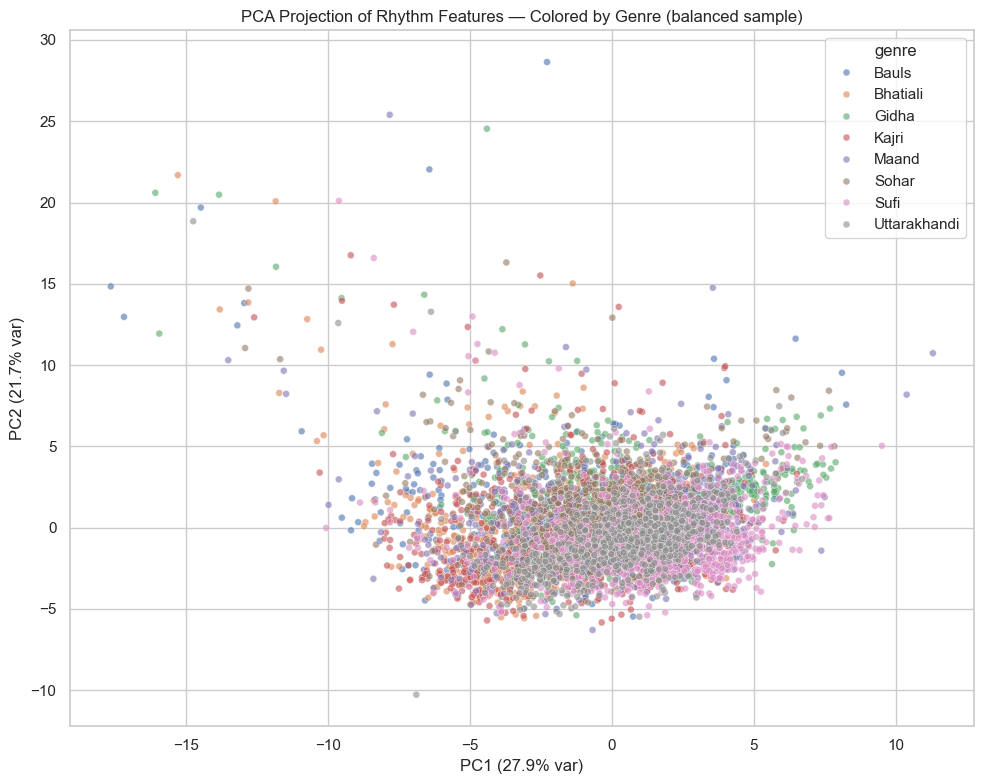

In [16]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=viz_sample_df, x="pc1", y="pc2", hue="genre", alpha=0.6, s=25)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA Projection of Rhythm Features — Colored by Genre (balanced sample)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_2d_by_genre.png", dpi=300)
plt.show()


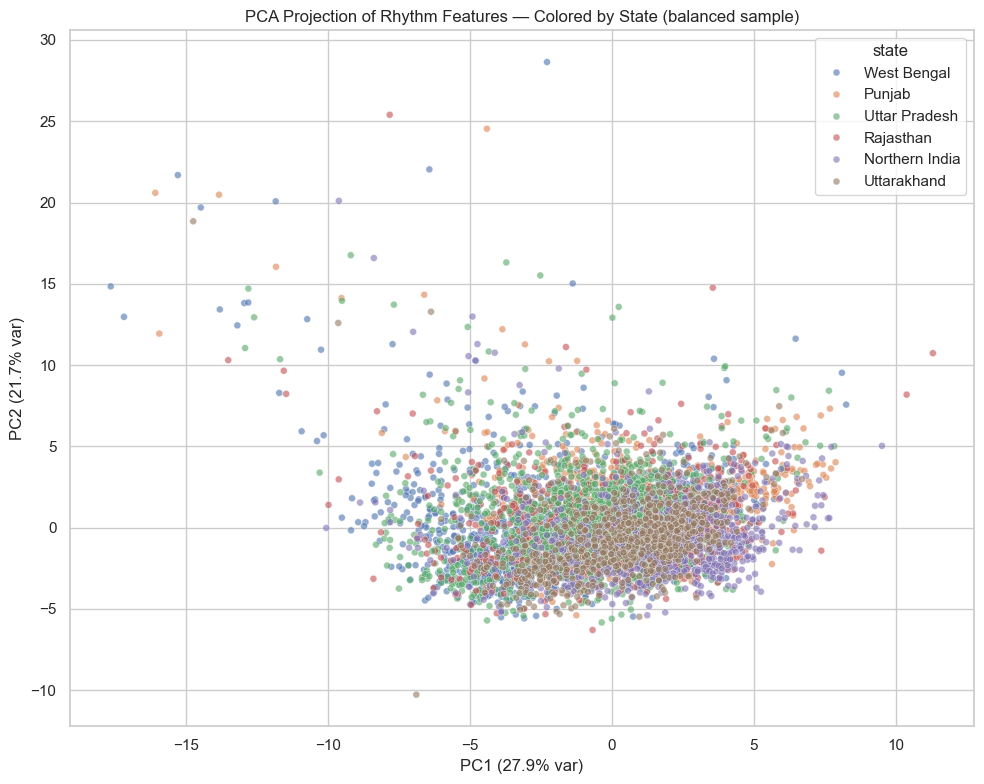

In [17]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=viz_sample_df, x="pc1", y="pc2", hue="state", alpha=0.6, s=25)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA Projection of Rhythm Features — Colored by State (balanced sample)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_2d_by_state.png", dpi=300)
plt.show()


## 6. K-Means: model selection

In [18]:
K_RANGE = range(2, 11)
SILHOUETTE_SAMPLE_SIZE = 5000

kmeans_results = []

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    sil_score = silhouette_score(
        X_scaled, labels,
        sample_size=min(SILHOUETTE_SAMPLE_SIZE, X_scaled.shape[0]),
        random_state=RANDOM_STATE,
    )
    db_score = davies_bouldin_score(X_scaled, labels)

    kmeans_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": sil_score,
        "davies_bouldin_score": db_score,
    })

kmeans_eval_df = pd.DataFrame(kmeans_results)
kmeans_eval_df.to_csv(TABLES_DIR / "kmeans_evaluation_metrics.csv", index=False)
kmeans_eval_df


,k,inertia,silhouette_score,davies_bouldin_score
0,2,2.948177e+06,0.220353,1.818927
1,3,2.634993e+06,0.209441,1.572420
2,4,2.408607e+06,0.143676,1.669091
3,5,2.235319e+06,0.135223,1.653968
4,6,2.121426e+06,0.130497,1.739377
5,7,2.014914e+06,0.126977,1.626214
6,8,1.924575e+06,0.141597,1.488476
7,9,1.821027e+06,0.139840,1.472368
8,10,1.752675e+06,0.117519,1.544624


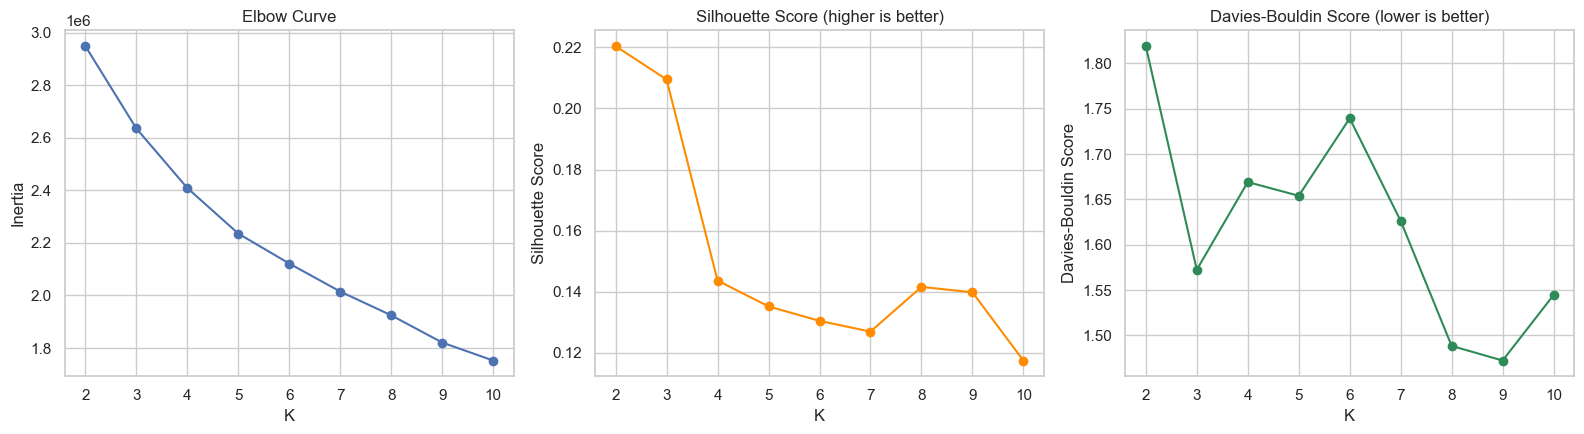

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(kmeans_eval_df["k"], kmeans_eval_df["inertia"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Curve")

axes[1].plot(kmeans_eval_df["k"], kmeans_eval_df["silhouette_score"], marker="o", color="darkorange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score (higher is better)")

axes[2].plot(kmeans_eval_df["k"], kmeans_eval_df["davies_bouldin_score"], marker="o", color="seagreen")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Davies-Bouldin Score")
axes[2].set_title("Davies-Bouldin Score (lower is better)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_evaluation_metrics.png", dpi=300)
plt.show()


In [20]:
BEST_K = int(kmeans_eval_df.loc[kmeans_eval_df["silhouette_score"].idxmax(), "k"])
BEST_K


2

`BEST_K` is selected as the K maximizing silhouette score within the tested range, cross-checked against the Davies-Bouldin curve and elbow curve above. This is a data-driven but not uniquely "correct" choice; the metric plot is reported so the choice is auditable.

## 7. Final K-Means model and cluster visualization in PCA space

In [21]:
final_kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

pca_df["cluster"] = cluster_labels
meta_df_clean["cluster"] = cluster_labels


C:\Users\ankit\AppData\Local\Temp\ipykernel_10604\1028155624.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), max_per_group), random_state=random_state))


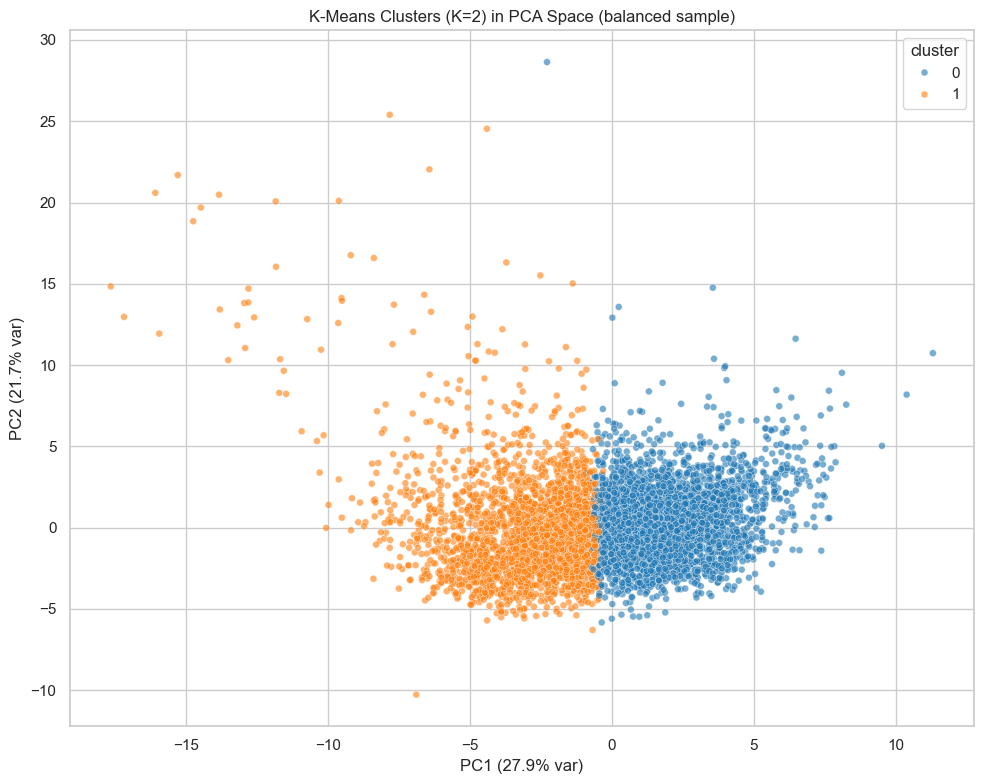

In [22]:
viz_sample_df = balanced_sample(pca_df, "genre", MAX_PER_GENRE, RANDOM_STATE)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=viz_sample_df, x="pc1", y="pc2",
    hue="cluster", palette="tab10", alpha=0.6, s=25,
)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title(f"K-Means Clusters (K={BEST_K}) in PCA Space (balanced sample)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_clusters_pca.png", dpi=300)
plt.show()


## 8. Cluster vs genre contingency table

In [23]:
contingency_table = pd.crosstab(meta_df_clean["cluster"], meta_df_clean["genre"])
contingency_table.to_csv(TABLES_DIR / "cluster_genre_contingency_table.csv")
contingency_table


genre,Bauls,Bhatiali,Gidha,Kajri,Maand,Sohar,Sufi,Uttarakhandi
cluster,,,,,,,,
0,4584,3671,5355,11383,12034,7115,14496,8980
1,3866,5137,2873,9197,5762,5879,4717,4040


## 9. Cluster composition percentages

In [24]:
cluster_composition_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
cluster_composition_pct = cluster_composition_pct.round(2)
cluster_composition_pct.to_csv(TABLES_DIR / "cluster_composition_percentages.csv")
cluster_composition_pct


genre,Bauls,Bhatiali,Gidha,Kajri,Maand,Sohar,Sufi,Uttarakhandi
cluster,,,,,,,,
0,6.78,5.43,7.92,16.83,17.80,10.52,21.44,13.28
1,9.32,12.39,6.93,22.18,13.89,14.18,11.37,9.74


In [25]:
genre_composition_pct = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100
genre_composition_pct = genre_composition_pct.round(2)
genre_composition_pct.to_csv(TABLES_DIR / "genre_cluster_distribution_percentages.csv")
genre_composition_pct


genre,Bauls,Bhatiali,Gidha,Kajri,Maand,Sohar,Sufi,Uttarakhandi
cluster,,,,,,,,
0,54.25,41.68,65.08,55.31,67.62,54.76,75.45,68.97
1,45.75,58.32,34.92,44.69,32.38,45.24,24.55,31.03


## 10. Hierarchical clustering on genre-level centroids

In [26]:
genre_feature_df = feature_df_clean.copy()
genre_feature_df["genre"] = meta_df_clean["genre"].values

genre_centroids, centroid_feature_cols = compute_group_centroids(
    genre_feature_df, group_col="genre", feature_cols=valid_feature_cols, normalize=True,
)
genre_centroids


,energy_mean,energy_std,energy_max,energy_min,energy_range,energy_skew,flux_mean,flux_std,flux_max,flux_sum,...,rhythm_hist_entropy,rhythm_hist_std,tempogram_dominant_lag,tempogram_mean_energy,tempogram_var,onset_mean,onset_std,onset_max,onset_peak_count,onset_density
genre,,,,,,,,,,,,,,,,,,,,,
Bauls,-0.462616,0.087359,-0.482279,-0.462199,0.149431,-0.145412,-0.027991,-0.047243,0.039478,-0.027991,...,-0.136541,0.153925,0.000617,-0.002636,0.116203,-0.090794,-0.054396,0.029643,-0.166784,-0.166784
Bhatiali,-0.385283,-0.096207,-0.480450,-0.190978,-0.194995,0.181192,-0.523511,-0.480756,-0.430280,-0.523511,...,-0.196065,0.203675,-0.017393,-0.042370,0.564507,-0.522436,-0.488031,-0.435423,-0.332701,-0.332701
Gidha,-0.237418,0.368116,-0.207139,-0.484744,0.429429,-0.361464,0.581132,0.446810,0.321014,0.581132,...,-0.066924,0.127206,-0.022587,0.013593,-0.152394,0.541404,0.418253,0.312297,0.305685,0.305685
Kajri,-0.160371,-0.072827,-0.163440,-0.041477,-0.096309,0.198726,-0.166696,-0.129886,-0.024160,-0.166696,...,-0.150135,0.157321,-0.020682,0.020927,-0.024142,-0.194449,-0.140030,-0.031457,-0.153812,-0.153812
Maand,0.336368,0.058474,0.472657,0.289446,0.062229,0.173178,0.047217,0.072599,0.025300,0.047217,...,0.052239,-0.083605,0.000918,-0.032446,0.020399,0.092320,0.063266,0.023624,-0.030658,-0.030658
Sohar,-0.432719,0.207142,-0.396583,-0.525009,0.307829,-0.228022,0.248995,0.098133,0.172850,0.248995,...,-0.192213,0.271515,-0.022587,0.004973,0.146355,0.042049,0.106733,0.177708,-0.190769,-0.190769
Sufi,0.233369,-0.160447,0.211089,0.293476,-0.181751,0.083785,-0.027911,0.105639,-0.013925,-0.027911,...,0.340470,-0.386429,0.069262,0.017346,-0.409060,0.186222,0.114477,-0.002001,0.472953,0.472953
Uttarakhandi,0.592137,-0.159018,0.465525,0.496330,-0.208283,-0.246664,-0.003288,-0.074221,-0.085751,-0.003288,...,0.118868,-0.153206,-0.022587,0.002494,0.106848,-0.065382,-0.039443,-0.078999,-0.082364,-0.082364


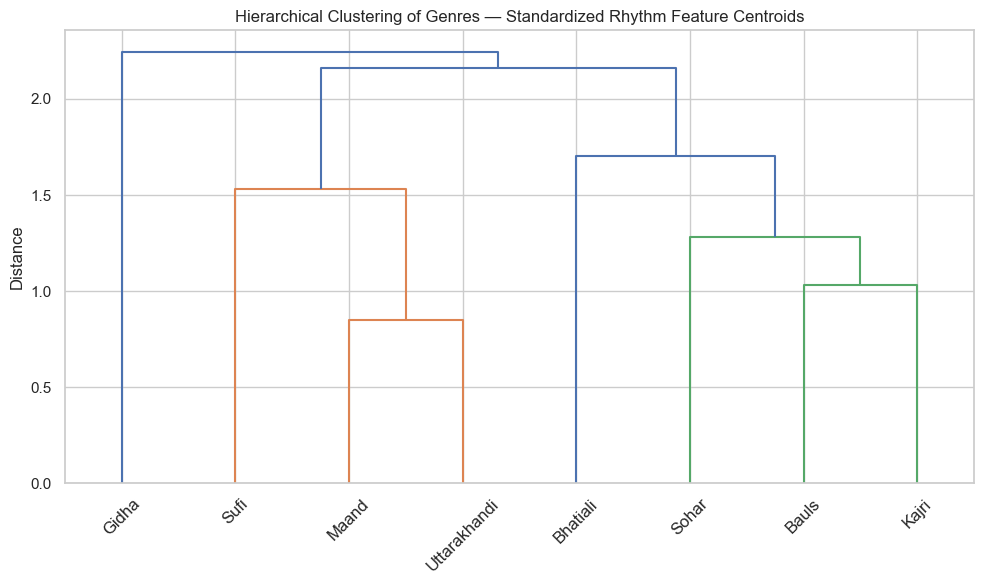

In [27]:
linkage_matrix = linkage(genre_centroids.to_numpy(), method="average", metric="euclidean")

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=genre_centroids.index.tolist(), leaf_rotation=45)
plt.ylabel("Distance")
plt.title("Hierarchical Clustering of Genres — Standardized Rhythm Feature Centroids")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "genre_hierarchical_dendrogram.png", dpi=300)
plt.show()


## 11. Genre clustering interpretation

In [28]:
GENRE_LINK_THRESHOLD_FRACTION = 0.5
threshold = GENRE_LINK_THRESHOLD_FRACTION * linkage_matrix[:, 2].max()

flat_genre_clusters = fcluster(linkage_matrix, t=threshold, criterion="distance")
genre_cluster_map = pd.DataFrame({
    "genre": genre_centroids.index,
    "hierarchical_group": flat_genre_clusters,
}).sort_values(["hierarchical_group", "genre"]).reset_index(drop=True)

genre_cluster_map.to_csv(TABLES_DIR / "genre_hierarchical_groups.csv", index=False)
genre_cluster_map


,genre,hierarchical_group
0,Maand,1
1,Uttarakhandi,1
2,Sufi,2
3,Bauls,3
4,Kajri,3
5,Sohar,4
6,Bhatiali,5
7,Gidha,6


In [29]:
group_sizes = genre_cluster_map.groupby("hierarchical_group")["genre"].apply(list)

grouped_genres = group_sizes[group_sizes.apply(len) > 1]
isolated_genres = group_sizes[group_sizes.apply(len) == 1]

print("Genres grouped together at this linkage threshold:")
for group_id, genres in grouped_genres.items():
    print(f"  Group {group_id}: {genres}")

print()
print("Genres that remain isolated (no close match) at this linkage threshold:")
for group_id, genres in isolated_genres.items():
    print(f"  {genres[0]}")


Genres grouped together at this linkage threshold:
  Group 1: ['Maand', 'Uttarakhandi']
  Group 3: ['Bauls', 'Kajri']

Genres that remain isolated (no close match) at this linkage threshold:
  Sufi
  Sohar
  Bhatiali
  Gidha


**Interpretation notes (numerical evidence only):**

- The groupings above reflect proximity of **standardized rhythm-feature
  centroids** under average-linkage hierarchical clustering, at a distance
  threshold set to 50% of the maximum linkage distance in this dendrogram.
- Genres listed in the same group have rhythm feature centroids that are
  numerically closer to each other than to other genres, at this threshold.
- Isolated genres have rhythm feature centroids that are comparatively
  distant from every other genre's centroid in this feature space.
- This is an **exploratory, unsupervised** result based on a specific
  feature set, scaling choice, linkage method, and threshold. It does
  **not** establish that these genres are musicologically or culturally
  related, and it does not constitute statistical hypothesis testing.
  Changing the feature set, distance metric, or threshold could change
  the groupings shown here.
- The K-Means cluster-vs-genre contingency table (Section 8) and
  composition percentages (Section 9) provide a complementary,
  segment-level view of the same question and should be read alongside
  this centroid-level dendrogram rather than in isolation.